# **Child Well-being - POSet analysis**<br/>
**University: University of Milano-Bicocca**  
**Master's Degree: Data Science (A.Y. 2025/2026)**  
**Course: Data Science Lab**  

---  
Use the Python Porting of R package `poseticDataAnalysis` by Avellone, De Capitani, Fattore.  
Added some implementations to work with Polars dataframes and handle `null` values ​​as uncertainty intervals in the hyperlattice.

**reference:**  
Fattore M., De Capitani L., Avellone A., Suardi A. (2024).  
*A fuzzy posetic toolbox for multi-criteria evaluation on ordinal data systems.*  
Annals of Operations Research. [doi:10.1007/s10479-024-06352-3](https://link.springer.com/article/10.1007/s10479-024-06352-3?utm_source=researchgate.net&utm_medium=article)

In [27]:
import sys; sys.path.insert(0, "..")
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import poset as P
import pickle

---
## 0. Summary of available functions

| Categoria | Funzioni |
|-----------|----------|
| **Constructors** | `POSet`, `LinearPOSet`, `BinaryVariablePOSet` |
| **Operations** | `ProductPOSet`, `DisjointSumPOSet`, `LinearSumPOSet`, `DualPOSet`, `IntersectionPOSet`, `LiftingPOSet`, `LexicographicProductPOSet`, `CrownPOSet`, `FencePOSet` |
| **Relations** | `IsReflexive`, `IsSymmetric`, `IsAntisymmetric`, `IsTransitive`, `IsPartialOrder`, `IsPreorder`, `TransitiveClosure`, `ReflexiveClosure` |
| **Query** | `POSetElements`, `DominanceMatrix`, `Dominates`, `IsDominatedBy`, `IsComparableWith`, `IsIncomparableWith`, `ComparabilitySetOf`, `IncomparabilitySetOf`, `UpsetOf`, `DownsetOf`, `POSetMaximals`, `POSetMinimals`, `CoverRelation`, `CoverMatrix`, `POSetMeet`, `POSetJoin`, `IsExtensionOf` |
| **Linear extensions** | `LEGenerator`, `LEBubleyDyer`, `LEGet` |
| **MRP** | `ExactMRP`, `BubleyDyerMRPGenerator`, `BubleyDyerMRP`, `LexMRP` |
| **Separation** | `ExactSeparation`, `BuildBubleyDyerSeparationGenerator`, `BubleyDyerSeparation`, `LexSeparation` |
| **Evaluation** | `ExactEvaluation`, `BuildBubleyDyerEvaluationGenerator`, `BubleyDyerEvaluation` |
| **Dominance** | `BLSDominance` |
| **Fuzzy** | `FuzzyInBetweenness`, `FuzzyInBetweennessMinMax`, `FuzzyInBetweennessProbabilistic`, `FuzzySeparation`, `FuzzySeparationMinMax`, `FuzzySeparationProbabilistic` |
| **Embedding** | `BidimensionalPosetRepresentation`, `OptimalBidimensionalEmbedding` |

## 1. Import POSets

In [28]:
n_levels_macro = 3
path = f"../data/050_posets_macro_dimensions_{n_levels_macro}_level.pkl"
with open(path, "rb") as f:
    results = pickle.load(f)

### 1.1 Select POSet to explore

In [29]:
df_macro_2015= pl.read_parquet("../data/040_indicators_macro_dim_3_level_2015.parquet")
df_exp_2015= pl.read_parquet("../data/040_public_expenditure_dim_discrete_3_level_2015.parquet")
df_macro_2018 = pl.read_parquet("../data/040_indicators_macro_dim_3_level_2018.parquet")
df_exp_2018 = pl.read_parquet("../data/040_public_expenditure_dim_discrete_3_level_2018.parquet")

---
## 1. Mutual Ranking Probabilities (MRP)  2015

In [30]:
result_sel15 = results['ind_2015'] 

In [31]:
# Try the MRP generator for a larger number of iterations to get more stable results.
# Note: this will take a while to run, especially for the possible poset, which is much larger than the certain one.
n = 30_000
seed = 42
gen = P.BubleyDyerMRPGenerator(result_sel15['poset_certain'], seed=seed)
mrp_cert = P.BubleyDyerMRP(gen, n=n)
poss = P.BubleyDyerMRPGenerator(result_sel15['poset_possible'], seed=seed)
mrp_poss = P.BubleyDyerMRP(poss, n=n)

In [25]:
# Exact MRP (without sampling) for comparison.
# Note: this will be very fast for the certain poset, 
# but will take a very long time to run for all the possible poset, which is much larger than the certain one.
#mrp_cert = P.ExactMRP(result_sel15poset_certain'])
#mrp_poss = P.ExactMRP(result_sel15poset_possible'])

In [32]:
def plot_mrp_ranking(
    elements: list,
    mrp_certain: dict,
    mrp_possible: dict | None = None,
    figsize: tuple = (14, 6),
    suptitle: str = "MRP Ranking Comparison",
    shorten_labels: bool = True,
    label_sep: str = "_",
    cmap_name: str = "RdYlGn",
    cmap_range: tuple = (0.15, 0.85),
    bar_height: float = 0.7,
    bar_edgecolor: str = "white",
    bar_linewidth: float = 0.8,
    font_family: str = "sans-serif",
    save_path: str | None = None,
    dpi: int = 200,
):
    """
    Horizontal bar chart of MRP scores, one or two panels.

    Parameters
    ----------
    elements : list of str
        Element labels from the POSet.
    mrp_certain : dict
        Output of ExactMRP or BubleyDyerMRP for the certain POSet.
    mrp_possible : dict, optional
        Same for possible POSet. If None, single-panel plot.
    shorten_labels : bool
        Shorten 'SWE_2015' → 'SWE'.
    cmap_name : str
        Matplotlib colormap.
    cmap_range : tuple
        (min, max) range within the colormap to avoid extreme ends.
    """
    import matplotlib
    matplotlib.rcParams.update({
        "font.family": font_family,
        "font.size": 11,
        "axes.titlesize": 13,
        "axes.labelsize": 11,
    })

    # Build panels
    panels = [
        (mrp_certain["MRP"].mean(axis=0), "Ranking MRP — POSet CERTAIN"),
    ]
    if mrp_possible is not None:
        panels.append(
            (mrp_possible["MRP"].mean(axis=0), "Ranking MRP — POSet POSSIBLE"),
        )

    n_panels = len(panels)
    fig, axes = plt.subplots(1, n_panels, figsize=figsize)
    if n_panels == 1:
        axes = [axes]

    cmap = plt.colormaps.get_cmap(cmap_name)

    for ax, (scores, title) in zip(axes, panels):
        # Sort by score descending
        ranked = sorted(zip(elements, scores), key=lambda x: -x[1])
        countries = [r[0] for r in ranked]
        vals = [r[1] for r in ranked]

        # Shorten labels
        if shorten_labels:
            display = [c.split(label_sep)[0] if label_sep in c else c for c in countries]
        else:
            display = countries

        # Colors: map score to colormap (highest = green, lowest = red)
        n = len(vals)
        color_positions = np.linspace(cmap_range[1], cmap_range[0], n)
        colors = [cmap(p) for p in color_positions]

        # Plot bottom-to-top so highest score is at the top
        y_pos = np.arange(n)
        ax.barh(
            y_pos, vals[::-1],
            height=bar_height,
            color=colors[::-1],
            edgecolor=bar_edgecolor,
            linewidth=bar_linewidth,
        )
        ax.set_yticks(y_pos)
        ax.set_yticklabels(display[::-1])

        # Score annotations
        for i, v in enumerate(vals[::-1]):
            ax.text(
                v + 0.015, i, f"{v:.2f}",
                va="center", fontsize=9, color="#333",
            )

        ax.set_xlabel("Average MRP Score")
        ax.set_title(title, fontweight="bold")
        ax.set_xlim(0, 1.12)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.grid(axis="x", alpha=0.2, linestyle="--")

    fig.suptitle(suptitle, fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
        print(f"Saved to {save_path}")

    plt.show()
    return fig, axes

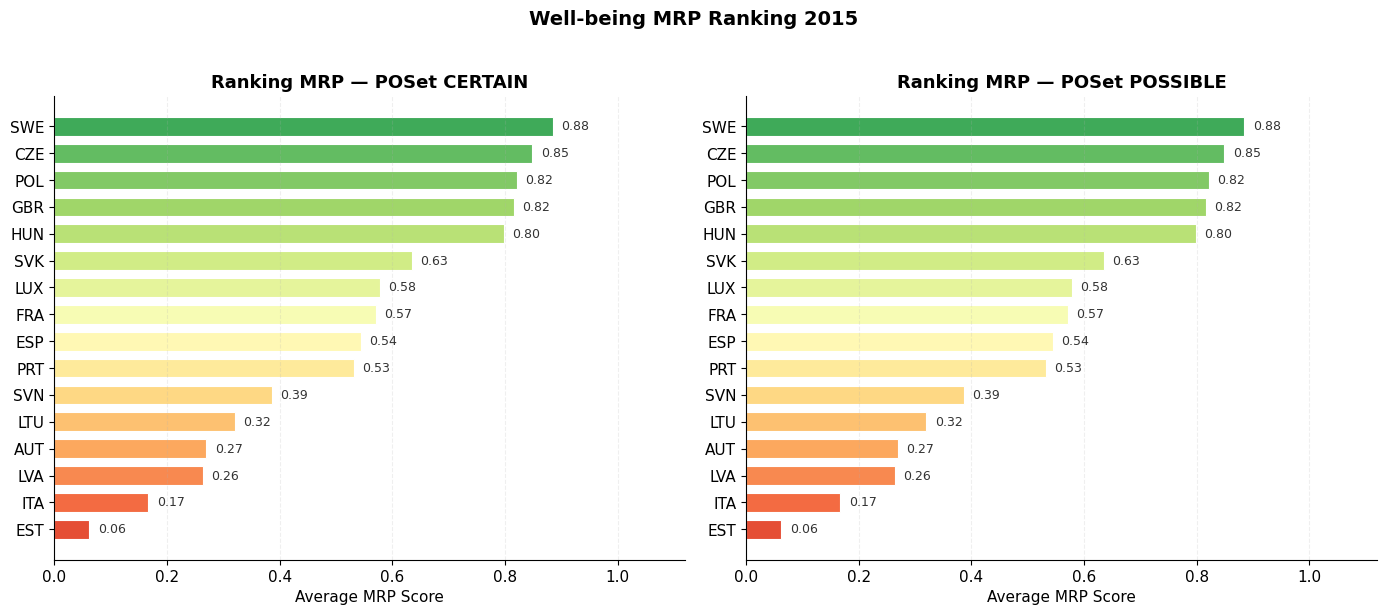

In [33]:
fig, axes = plot_mrp_ranking(
    elements=result_sel15["elements"],
    mrp_certain=mrp_cert,
    mrp_possible=mrp_poss,
    suptitle="Well-being MRP Ranking 2015",
    dpi=200,
)

In [10]:
def plot_profile_heatmap(
    df: "pl.DataFrame",
    mrp_result: dict | None = None,
    id_col: str = "REF_AREA",
    title: str = "Macro-dimension profiles by country",
    figsize: tuple | None = None,
    n_levels: int = 3,
    shorten_labels: bool = True,
    label_sep: str = "_",
    save_path: str | None = None,
    dpi: int = 200,
):
    """
    Clean heatmap of ordinal profiles per country.
    """
    import matplotlib
    import matplotlib.colors as mcolors
    matplotlib.rcParams.update({
        "font.family": "sans-serif",
        "font.size": 11,
    })

    # Extract data
    exclude = {"REF_AREA", "TIME_PERIOD", "__unit_id__"}
    dim_cols = [c for c in df.columns if c not in exclude]
    id_values = df[id_col].to_list()
    matrix = df.select(dim_cols).to_numpy().astype(float)
    n_countries = len(id_values)
    n_dims = len(dim_cols)

    # Auto figsize
    if figsize is None:
        figsize = (max(8, n_dims * 2.5 + 3), max(6, n_countries * 0.55 + 2))

    # Shorten labels
    if shorten_labels:
        display_labels = [
            c.split(label_sep)[0] if label_sep in c else c
            for c in id_values
        ]
    else:
        display_labels = id_values

    # Prettify dimension names
    dim_display = [c.replace("_", " ").title() for c in dim_cols]

    # Sort by MRP score
    if mrp_result is not None:
        elements = mrp_result["elements"]
        scores = mrp_result["MRP"].mean(axis=0)
        elem_to_score = dict(zip(elements, scores))

        id_to_score = {}
        for raw_id, display in zip(id_values, display_labels):
            for e in elements:
                e_short = e.split(label_sep)[0] if label_sep in e else e
                if e_short == display or e == raw_id:
                    id_to_score[raw_id] = elem_to_score[e]
                    break

        sort_order = sorted(
            range(len(id_values)),
            key=lambda i: id_to_score.get(id_values[i], 0),
            reverse=True,
        )
    else:
        id_to_score = {}
        sort_order = sorted(range(len(id_values)), key=lambda i: display_labels[i])

    matrix = matrix[sort_order]
    sorted_ids = [id_values[i] for i in sort_order]
    display_labels = [display_labels[i] for i in sort_order]

    # Discrete colormap: 3 distinct colours
    level_colors = ["#d9534f", "#f0c36d", "#5cb85c"]  # red, amber, green
    cmap_discrete = mcolors.ListedColormap(level_colors[:n_levels])
    bounds = np.arange(0.5, n_levels + 1.5, 1)
    norm = mcolors.BoundaryNorm(bounds, cmap_discrete.N)

    # Plot
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(matrix, cmap=cmap_discrete, norm=norm, aspect="auto")

    # Cell annotations: level number
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            val = matrix[i, j]
            if np.isnan(val):
                ax.text(j, i, "—", ha="center", va="center",
                        fontsize=13, color="#999")
            else:
                ax.text(j, i, f"{int(val)}", ha="center", va="center",
                        fontsize=14, fontweight="bold", color="white")

    # Y-axis: country + MRP score
    if mrp_result is not None:
        y_labels = [
            f"{lbl}  ({id_to_score.get(rid, 0):.2f})"
            for lbl, rid in zip(display_labels, sorted_ids)
        ]
    else:
        y_labels = display_labels

    ax.set_yticks(range(len(y_labels)))
    ax.set_yticklabels(y_labels, fontsize=10)

    # X-axis on top, horizontal
    ax.set_xticks(range(n_dims))
    ax.set_xticklabels(dim_display, fontsize=11, fontweight="bold")
    ax.xaxis.set_ticks_position("top")
    ax.xaxis.set_label_position("top")

    # Grid
    ax.set_xticks(np.arange(-0.5, n_dims, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n_countries, 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=2.5)
    ax.tick_params(which="minor", size=0)

    # Legend instead of colorbar
    from matplotlib.patches import Patch
    legend_patches = [
        Patch(facecolor=level_colors[i], edgecolor="white", label=f"Level {i+1}")
        for i in range(n_levels)
    ]
    ax.legend(
        handles=legend_patches,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.08),
        ncol=n_levels,
        frameon=False,
        fontsize=10,
    )

    ax.set_title(title, fontsize=14, fontweight="bold", pad=15)
    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
        print(f"Saved to {save_path}")

    plt.show()
    return fig, ax

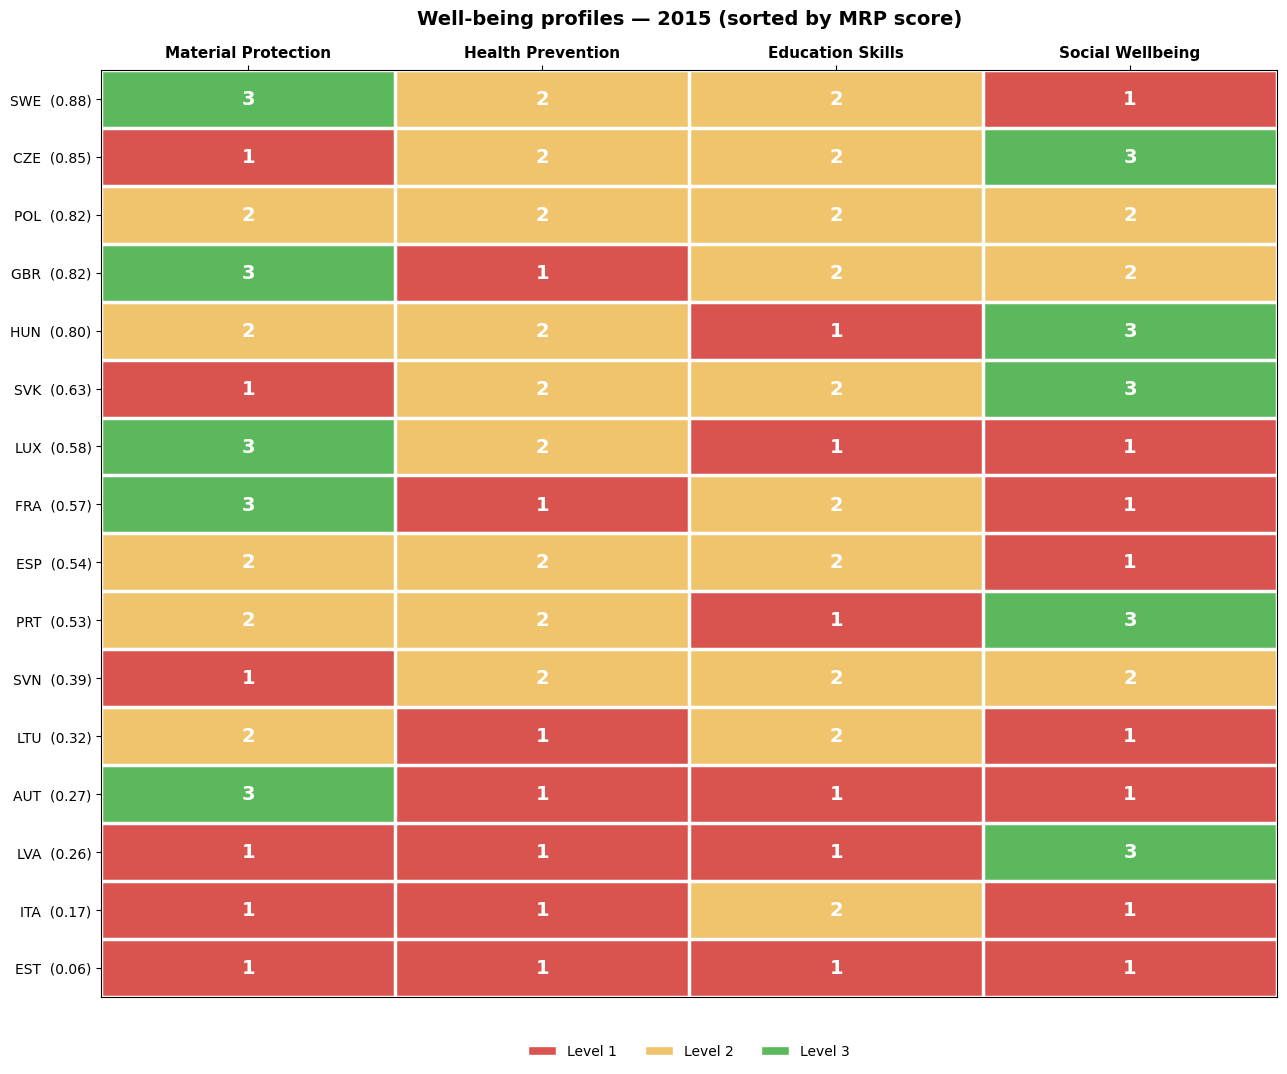

In [11]:
fig, ax = plot_profile_heatmap(
    df=df_macro_2015,
    mrp_result=mrp_cert,
    title="Well-being profiles — 2015",
)

***
# 2. Mutual Ranking Probabilities (MRP)  2018

In [12]:
result_sel18 = results['ind_2018'] 

In [13]:
n = 30_000
seed = 42
gen = P.BubleyDyerMRPGenerator(result_sel18['poset_certain'], seed=seed)
mrp_cert = P.BubleyDyerMRP(gen, n=n)
poss = P.BubleyDyerMRPGenerator(result_sel18['poset_possible'], seed=seed)
mrp_poss = P.BubleyDyerMRP(poss, n=n)

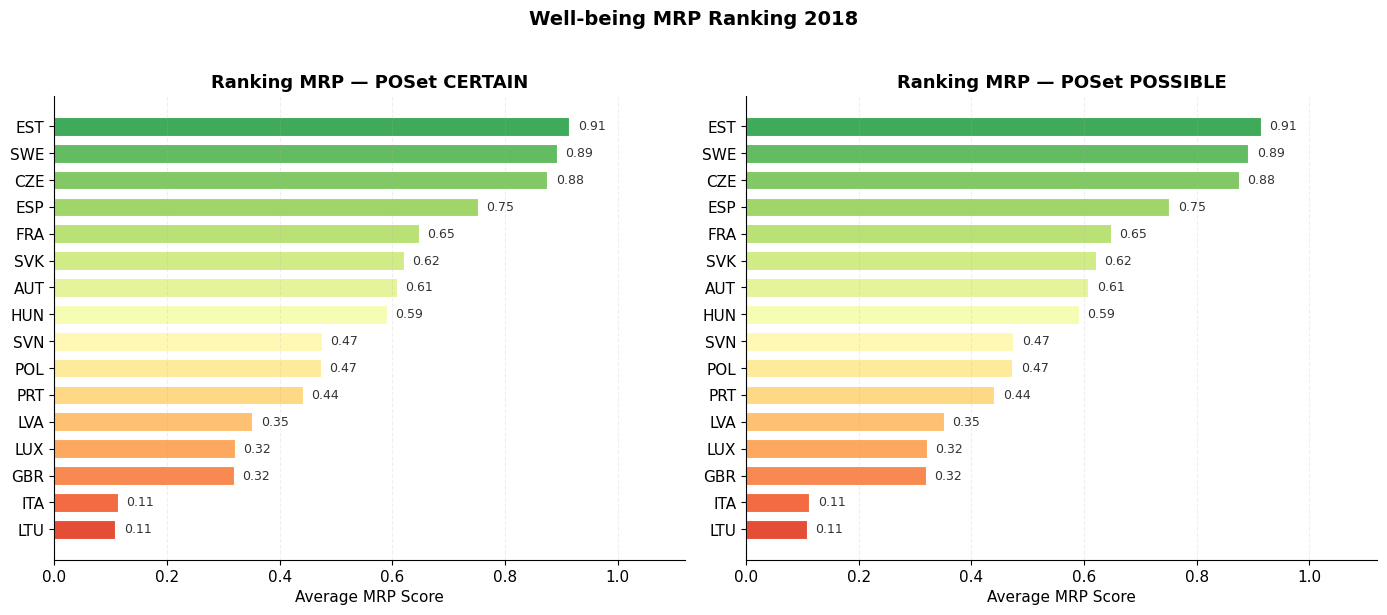

In [14]:
fig, axes = plot_mrp_ranking(
    elements=result_sel18["elements"],
    mrp_certain=mrp_cert,
    mrp_possible=mrp_poss,
    suptitle="Well-being MRP Ranking 2018",
    dpi=200,
)

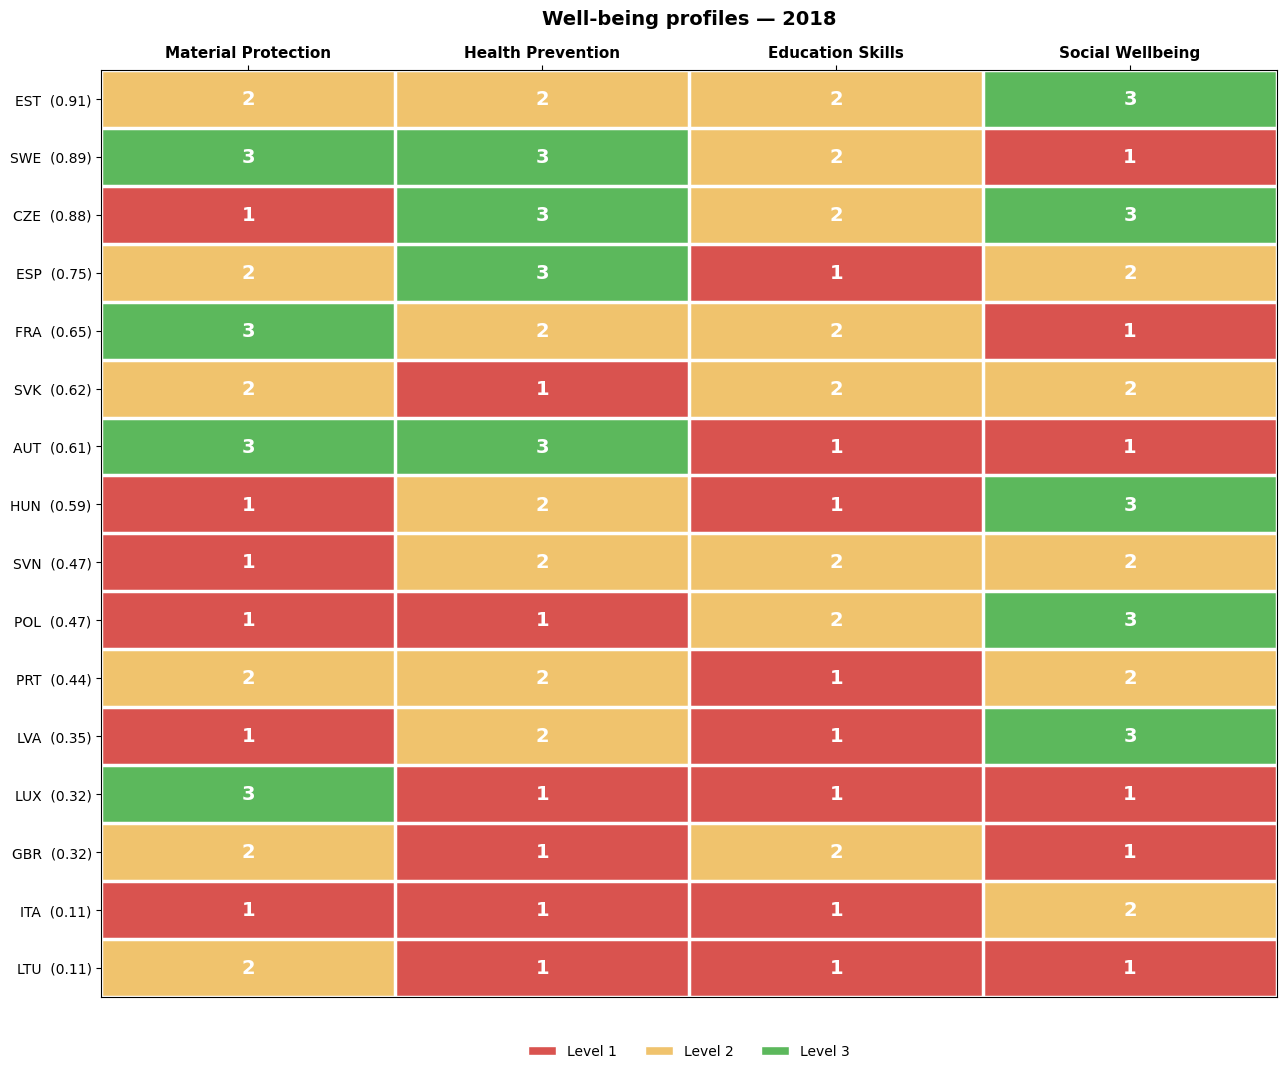

In [16]:
fig, ax = plot_profile_heatmap(
    df=df_macro_2018,
    mrp_result=mrp_cert,
    title="Well-being profiles — 2018",
)

***

### **Case Study: Validating the "Estonian Miracle"**
A preliminary review of the 2015 vs. 2018 MRP rankings reveals a massive anomaly: **Estonia (EST)** leaps from the bottom tier of the lattice in 2015 to the absolute top in 2018. 

In socio-economic data, a shift of this magnitude in just 36 months is highly irregular. Before accepting this as a genuine policy success, we must run a diagnostic check on the raw, pre-normalized data to rule out two common data artifacts:
1. **The Missing Data Penalty:** Did Estonia have blank data in 2015 that the POSet algorithm penalized with a "worst-case" assumption?
2. **OECD Reporting Shifts:** Did Estonia change its reporting methodology, causing an artificial spike in the raw numbers?

In [20]:
# Load the base dataset BEFORE it was turned into POSet grades
df = pl.read_parquet('../data/020_child_well_being.parquet')

# Isolate Estonia for the two years in question
df_est = df.filter(
    (pl.col('REF_AREA') == 'EST') & 
    (pl.col('TIME_PERIOD').is_in([2015, 2018]))
)

indicator_cols = [col for col in df.columns if col not in ['REF_AREA', 'TIME_PERIOD']]

# ---------------------------------------------------------
# POINT 1: CHECK FOR THE "MISSING DATA PENALTY"
# Count how many columns are 'null' for each year
# ---------------------------------------------------------
df_nulls = df_est.with_columns(
    pl.sum_horizontal(pl.col(indicator_cols).is_null()).alias('Total_Missing_Values')
).select(['REF_AREA', 'TIME_PERIOD', 'Total_Missing_Values'])

print("--- 1. MISSING DATA COUNT (ESTONIA) ---")
df_nulls

--- 1. MISSING DATA COUNT (ESTONIA) ---


REF_AREA,TIME_PERIOD,Total_Missing_Values
str,i64,u32
"""EST""",2018,0
"""EST""",2015,0


In [21]:
# ---------------------------------------------------------
# POINT 2: CHECK FOR "OECD REPORTING SHIFTS"
# Compare 2015 vs 2018 raw values side-by-side to find massive spikes
# ---------------------------------------------------------
# Note: If your Polars version is older, change .unpivot() to .melt()
df_melt = df_est.unpivot(
    index=["REF_AREA", "TIME_PERIOD"], 
    on=indicator_cols,
    variable_name="Indicator",
    value_name="Value"
)

df_pivot = df_melt.pivot(
    index="Indicator",
    on="TIME_PERIOD",
    values="Value"
)

# Add a column to see the absolute difference between 2018 and 2015
# and sort to show the biggest changes at the top
df_shifts = df_pivot.with_columns(
    (pl.col("2018") - pl.col("2015")).abs().alias("Absolute_Difference")
).sort("Absolute_Difference", descending=True)

print("\n--- 2. BIGGEST RAW VALUE SHIFTS (Top 10) ---")
df_shifts.head(10)


--- 2. BIGGEST RAW VALUE SHIFTS (Top 10) ---


Indicator,2018,2015,Absolute_Difference
str,f64,f64,f64
"""C4_4""",7407.7,6209.1,1198.6
"""C3_1""",1629.9,1412.3,217.6
"""C2_2""",651.8,583.4,68.4
"""C5_1""",248.2,211.8,36.4
"""C4_5""",53.6,68.7,15.1
"""B4_3""",24.5,34.8,10.3
"""C2_1""",110.4,104.4,6.0
"""C3_3""",87.0,93.0,6.0
"""B2_4""",25.4,20.2,5.2


In [23]:
pl.Config.set_tbl_cols(-1)

# 1. Load the raw extracted data from notebook 010
df_raw = pl.read_parquet('../data/010_child_well_being.parquet')

# 2. Filter for Estonia to see what the OECD actually returned
df_est_raw = df_raw.filter(pl.col('REF_AREA') == 'EST')

print("--- RAW OECD DATA FOR ESTONIA ---")
df_est_raw.sort('TIME_PERIOD')

--- RAW OECD DATA FOR ESTONIA ---


REF_AREA,TIME_PERIOD,A1_2,A1_4,A2_1,A3_3,A3_4,A3_5,A4_6,B1_1,B1_5,B2_1,B2_4,B2_5,B3_5,B4_3,C1_1,C1_2,C1_3,C1_4,C1_5,C2_1,C2_2,C2_3,C3_1,C3_2,C3_3,C4_1,C4_2,C4_3,C4_4,C4_5,C4_6,C5_1
str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""EST""",2009,null,3.8,3.6,16.2,null,19.0,null,null,null,null,null,null,null,null,4519.7,9.9,26.0,null,null,11.3,586.1,5.1,1191.6,95.3,95.0,1251.0,null,null,7112.4,null,null,183.4
"""EST""",2012,8.7,1.1,3.6,19.2,null,15.9,null,null,null,null,null,null,16.2,null,3959.7,6.8,29.0,166.0,2.0,179.3,507.6,10.0,1192.7,94.2,94.0,1318.8,6.0,null,6781.7,null,null,240.4
"""EST""",2015,4.8,0.8,2.5,20.4,64.9,12.8,36.9,12.1,36.6,null,20.2,78.0,12.4,34.8,5463.8,9.1,33.0,166.0,2.0,104.4,583.4,6.7,1412.3,93.2,93.0,3296.7,5.0,null,6209.1,68.7,12.2,211.8
"""EST""",2018,5.1,0.5,1.6,22.5,70.0,12.7,34.6,10.3,36.1,27.7,25.4,73.6,8.5,24.5,null,12.3,33.0,166.0,2.0,110.4,651.8,6.5,1629.9,91.9,87.0,null,5.0,null,7407.7,53.6,12.7,248.2


**Diagnostic Conclusion:** The raw data confirms that the missingness count is exactly 0 for the selected indicators, and the raw metric shifts are natural, not artificial spikes. The anomaly is not a data artifact. It mathematically captures Estonia's well-documented overhaul of its education system (PISA outcomes) and sweeping digital inclusion policies during this period.


The mathematical leap of Estonia from the minimal set in 2015 to the maximal set in 2018 is the direct reflection of two major structural overhauls that converged and matured during this specific time window:

* **The PISA Powerhouse:** Between 2015 and 2018, Estonia famously overtook the rest of Europe in the OECD's PISA education scores. They completely overhauled their school system to focus on equity and early childhood intervention. According to the OECD and independent academic reviews like *Estonia: A Positive PISA Experience* (Tire, 2021), this success was driven by highly autonomous schools, mandatory master's degrees for teachers, and a framework that ensures a student's academic performance is independent of their socio-economic background. 

* **e-Estonia:** During this exact window, Estonia heavily digitized its society and schooling, making internet access and digital literacy a fundamental right, which drastically spiked their digital well-being indicators. Building upon their historic "Tiger Leap" initiative, the Estonian Ministry of Education embedded digital competence as a cross-cutting subject across all curricula. By 2018, the country had achieved 100% adoption of e-solutions in schools (including digital databases, e-learning materials, and digital assessments), transforming traditional education into a highly efficient hybrid model. 

**References for Further Reading:**
* OECD/Ministry of Foreign Affairs Report: [PISA 2018: Estonia ranks first in Europe](https://oecd.mfa.ee/pisa-2018-estonia-ranks-first-in-europe/)
* Research Paper (Springer): [Estonia: A Positive PISA Experience (Tire, 2021)](https://www.researchgate.net/publication/347118454_Estonia_A_Positive_PISA_Experience)
* Official Government Framework: [e-Estonia Digital Guide](https://e-estonia.com/wp-content/uploads/eestonia_guide_08-04-2025.pdf)
* EU Policy Monitor: [Estonia - Better Internet for Kids](https://better-internet-for-kids.europa.eu/en/knowledge-hub/estonia-policy-monitor-country-profile)

*This notebook is licensed under [CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/).*